# Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset using pandas dataframe

In [2]:
dataset = pd.read_csv('Salary_Data_larger.csv')
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
dataset.shape

(6704, 6)

### Checking dataset type and various info

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 552.7 KB


In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


## checking for missing values as they can worsen the predictions and hamper in model training

In [6]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [7]:
dataset.dropna(inplace=True)

In [8]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


### Creating a copy of the main dataset -> not necessary but makes it flexible to work and fix issues

In [9]:
dataset_copy = dataset.copy()

dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


### Converting object types to string so that ML model can work -> most models need int/float only but as I am using CatBoost, it can work with string, float, and interger types.

In [10]:
dataset_copy["Gender"] = dataset_copy["Gender"].astype("string")
dataset_copy["Education Level"] = dataset_copy["Education Level"].astype("string")
dataset_copy["Job Title"] = dataset_copy["Job Title"].astype("string")

In [11]:
dataset_copy.dtypes

Age                    float64
Gender                  string
Education Level         string
Job Title               string
Years of Experience    float64
Salary                 float64
dtype: object

### Checking for duplicate values in the dataset as they can give exceptional training performance and worse testing results.

In [12]:
dataset_copy.duplicated().sum()

np.int64(4911)

In [13]:
dataset_copy = dataset_copy.drop_duplicates()

In [14]:
dataset_copy.duplicated().sum()

np.int64(0)

### Simplifying the string values for the model

In [15]:
dataset_copy["Gender"] = dataset_copy["Gender"].str.lower().str.strip()
dataset_copy["Education Level"] = dataset_copy["Education Level"].str.lower().str.strip()
dataset_copy["Job Title"] = dataset_copy["Job Title"].str.lower().str.strip()

In [16]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,bachelor's,software engineer,5.0,90000.0
1,28.0,female,master's,data analyst,3.0,65000.0
2,45.0,male,phd,senior manager,15.0,150000.0
3,36.0,female,bachelor's,sales associate,7.0,60000.0
4,52.0,male,master's,director,20.0,200000.0


### Here, I am fixing the education level columns value's as they are a bit irregular. For easier model understanding cleaning is done here.

In [17]:
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("phd","PhD")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's degree","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's degree","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("high school","High School")

In [18]:
dataset_copy.shape

(1787, 6)

### Final veiw of the dataset before feeding the data inside model

In [19]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,Bachelor,software engineer,5.0,90000.0
1,28.0,female,Master,data analyst,3.0,65000.0
2,45.0,male,PhD,senior manager,15.0,150000.0
3,36.0,female,Bachelor,sales associate,7.0,60000.0
4,52.0,male,Master,director,20.0,200000.0


## Dataset split for model training (single split checking)

In [20]:
x = dataset_copy.drop(columns=["Salary"])
y = dataset_copy["Salary"]

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Importing catboost model and assigning the categorical columns

In [22]:
from catboost import CatBoostRegressor

cat_features = ["Gender", "Education Level", "Job Title"]

### Default CatBoostRegressor model is used.

In [23]:
model = CatBoostRegressor()

In [24]:
model.fit(
    x_train,
    y_train,
    cat_features=cat_features,
    verbose=100
)

Learning rate set to 0.043319
0:	learn: 49831.4902915	total: 58.9ms	remaining: 58.9s
100:	learn: 18017.7845262	total: 114ms	remaining: 1.01s
200:	learn: 15811.4394141	total: 157ms	remaining: 624ms


300:	learn: 14480.7059105	total: 201ms	remaining: 467ms
400:	learn: 13550.8980290	total: 243ms	remaining: 363ms
500:	learn: 12826.3757906	total: 290ms	remaining: 288ms
600:	learn: 12188.6012288	total: 335ms	remaining: 222ms
700:	learn: 11711.7311553	total: 380ms	remaining: 162ms


800:	learn: 11227.6695465	total: 426ms	remaining: 106ms
900:	learn: 10840.3066758	total: 472ms	remaining: 51.9ms
999:	learn: 10463.4348396	total: 519ms	remaining: 0us


CatBoostRegressor(loss_function='RMSE')

In [25]:
predictions = model.predict(x_test)

### Performance measurement of the model

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(r2_score(y_test, predictions))
print(mean_absolute_error(y_test, predictions))
print(mean_squared_error(y_test, predictions))

0.8983603428550143
11576.081469158866
278486593.41453946


### Input function for manual testing

In [27]:
def predict_salary(age, gender, education, job_title, experience):
    
    
    user_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender.lower().strip()],
        "Education Level": [education],
        "Job Title": [job_title.lower().strip()],
        "Years of Experience": [experience]
    })
    
    prediction = model.predict(user_data)[0]
    
    return round(prediction, 2)

In [28]:
# use it for making predictions 

predict_salary(
    age=46,
    gender="Male",
    education="PhD",  # Bachelor, Master, PhD
    job_title="Manager",
    experience=2
)

np.float64(58072.63)

### SHAP Analysis -> it shows what's in the dataset is responsible for prediction

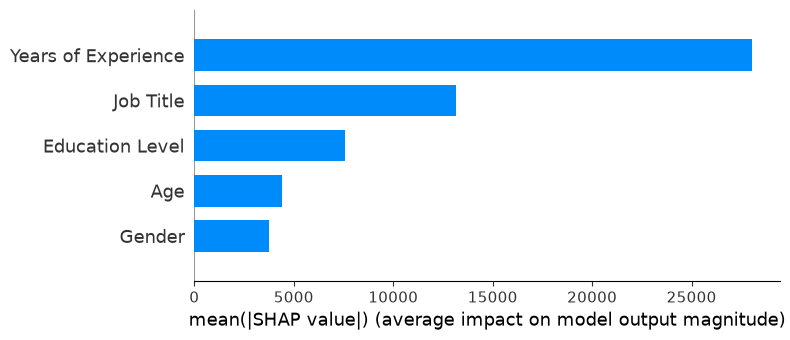

In [29]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test, plot_type="bar")

### SHAP dependence plots — does a feature's effect change across its range?

The summary plot above shows each feature's *average* importance, but not whether its effect is constant. A dependence plot shows, for one feature, how its SHAP contribution changes as the feature's own value changes -- e.g. does more experience always help equally, or does the effect taper off?

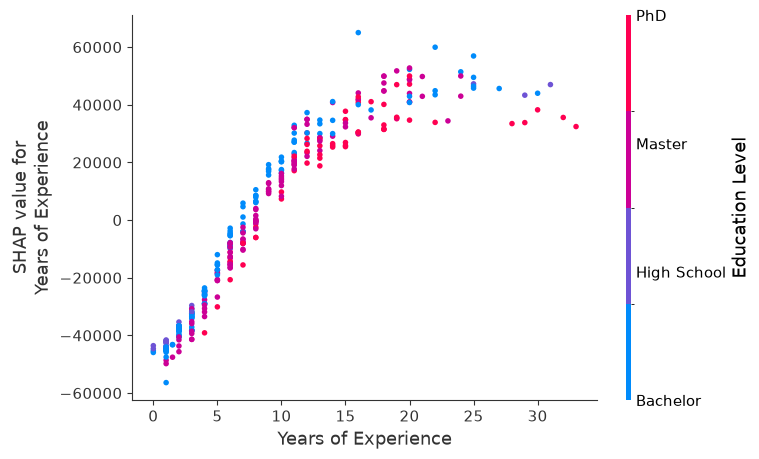

In [30]:
shap.dependence_plot("Years of Experience", shap_values, x_test)

Experience's contribution rises steeply up to roughly 15-20 years, then flattens and even dips slightly beyond ~25 -- the model has learned diminishing (and eventually slightly negative) returns to tenure, not a straight line. The colour (Education Level) shows little separation, so this pattern holds fairly consistently across education levels.

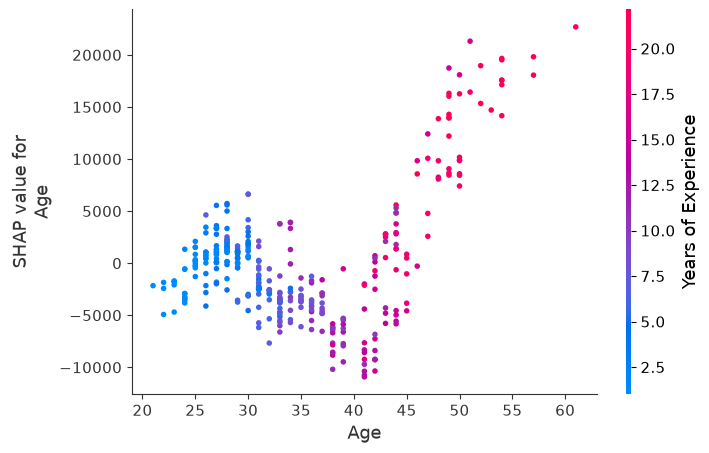

In [31]:
shap.dependence_plot("Age", shap_values, x_test)

Age's effect is not a simple "older is better" curve -- it dips into negative territory for ages 30-42 before rising sharply after 45. The colour (Years of Experience) explains why: the dip is concentrated among people with comparatively *low* experience for their age (blue/purple, 5-10 years), while the rise after 45 is driven by *high*-experience people (pink, 15-20+ years). In other words, the model isn't really using age on its own -- it's using age as a proxy for "is this person's experience unusually low or high for their stage of life", which only becomes visible once experience is shown as the interaction colour.

### Extending the bias analysis: does the gender effect change with seniority?

The live site's Model Insights page already runs a counterfactual gender-swap test showing a small but non-zero average gender effect on predictions. A dependence-style plot of Gender's own SHAP values against experience checks whether that effect is constant or grows/shrinks with seniority -- `shap.dependence_plot` doesn't handle a categorical main feature cleanly, so this one is built directly with matplotlib, colouring each point by the person's actual gender.

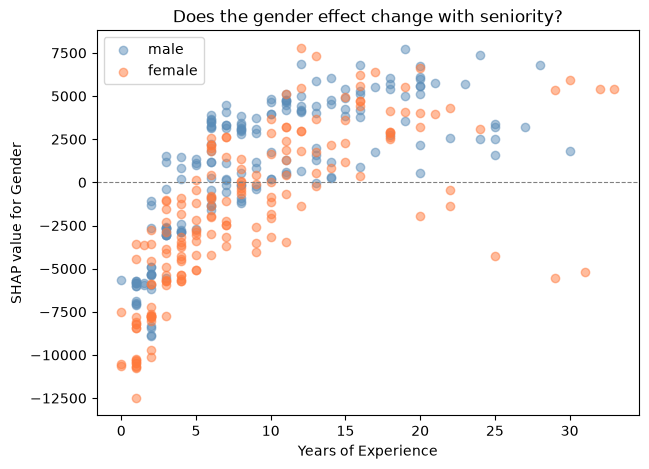

Male,   <10 yrs experience: mean SHAP = -1245  n= 104
Male,   >=10 yrs experience: mean SHAP = 3846  n= 76
Female, <10 yrs experience: mean SHAP = -4166  n= 112
Female, >=10 yrs experience: mean SHAP = 2255  n= 66


In [32]:
gender_idx = list(x_test.columns).index("Gender")
gender_shap = shap_values[:, gender_idx]
is_male = (x_test["Gender"] == "male").values
low_exp = x_test["Years of Experience"] < 10
high_exp = x_test["Years of Experience"] >= 10

plt.figure(figsize=(7, 5))
plt.scatter(x_test["Years of Experience"][is_male], gender_shap[is_male], alpha=0.5, label="male", color="#5B8DB8")
plt.scatter(x_test["Years of Experience"][~is_male], gender_shap[~is_male], alpha=0.5, label="female", color="#FF7A3D")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Years of Experience")
plt.ylabel("SHAP value for Gender")
plt.title("Does the gender effect change with seniority?")
plt.legend()
plt.show()

print("Male,   <10 yrs experience: mean SHAP =", round(gender_shap[is_male & low_exp].mean()), " n=", (is_male & low_exp).sum())
print("Male,   >=10 yrs experience: mean SHAP =", round(gender_shap[is_male & high_exp].mean()), " n=", (is_male & high_exp).sum())
print("Female, <10 yrs experience: mean SHAP =", round(gender_shap[~is_male & low_exp].mean()), " n=", (~is_male & low_exp).sum())
print("Female, >=10 yrs experience: mean SHAP =", round(gender_shap[~is_male & high_exp].mean()), " n=", (~is_male & high_exp).sum())

Both genders' SHAP contribution moves from negative (early career) to positive (10+ years) -- that part is just the model learning seniority matters, same as everyone. The relevant gap is *between* the lines: at low experience, women's mean SHAP value is noticeably more negative than men's (roughly a $2,900 wider penalty); at high experience the gap narrows to around $1,600. So the gender effect isn't constant -- it's larger early in a career than later, which is the opposite of what "the gap widens with seniority" would have predicted, and is itself a useful, more specific finding than the single overall average from the bias analysis page.

### Cross validation for checking model's performance on the entire dataset (better than single split analysis)

In [33]:
from catboost import Pool, cv

cat_features = ["Gender", "Education Level", "Job Title"]

# using 5-fold --> 4 fold contains data for training and 1 fold for testing, and repeats 5 times 
# --> so that all data gets used for both training and testing across the folds
train_pool = Pool(
    data=dataset_copy.drop("Salary", axis=1), 
    label=dataset_copy["Salary"],
    cat_features=cat_features
)

cv_results = cv(
    pool=train_pool,
    params={
        "loss_function": "RMSE",   
        "eval_metric": "R2"       
    },
    fold_count=5
)

print(cv_results.tail())

Training on fold [0/5]
0:	learn: -4.4662384	test: -4.6506262	best: -4.6506262 (0)	total: 396us	remaining: 396ms
1:	learn: -4.1776598	test: -4.3432323	best: -4.3432323 (1)	total: 2.21ms	remaining: 1.1s
2:	learn: -3.9143339	test: -4.0668484	best: -4.0668484 (2)	total: 3.41ms	remaining: 1.13s
3:	learn: -3.6548841	test: -3.7913195	best: -3.7913195 (3)	total: 6.12ms	remaining: 1.52s
4:	learn: -3.4075624	test: -3.5397832	best: -3.5397832 (4)	total: 8.92ms	remaining: 1.77s
5:	learn: -3.1767456	test: -3.2998139	best: -3.2998139 (5)	total: 11ms	remaining: 1.82s
6:	learn: -2.9702699	test: -3.0837663	best: -3.0837663 (6)	total: 12.2ms	remaining: 1.73s
7:	learn: -2.7740091	test: -2.8809977	best: -2.8809977 (7)	total: 14ms	remaining: 1.74s
8:	learn: -2.5892142	test: -2.6895248	best: -2.6895248 (8)	total: 14.9ms	remaining: 1.65s
9:	learn: -2.3977998	test: -2.4939126	best: -2.4939126 (9)	total: 15.4ms	remaining: 1.52s
10:	learn: -2.2280847	test: -2.3204019	best: -2.3204019 (10)	total: 16.1ms	remainin

206:	learn: 0.8855719	test: 0.8679312	best: 0.8679312 (206)	total: 186ms	remaining: 714ms
207:	learn: 0.8855917	test: 0.8679326	best: 0.8679326 (207)	total: 187ms	remaining: 712ms
208:	learn: 0.8860417	test: 0.8681547	best: 0.8681547 (208)	total: 188ms	remaining: 712ms
209:	learn: 0.8864993	test: 0.8685732	best: 0.8685732 (209)	total: 189ms	remaining: 710ms
210:	learn: 0.8866810	test: 0.8688254	best: 0.8688254 (210)	total: 189ms	remaining: 708ms


211:	learn: 0.8871679	test: 0.8691334	best: 0.8691334 (211)	total: 190ms	remaining: 706ms
212:	learn: 0.8874651	test: 0.8694251	best: 0.8694251 (212)	total: 191ms	remaining: 706ms
213:	learn: 0.8877554	test: 0.8696431	best: 0.8696431 (213)	total: 192ms	remaining: 704ms
214:	learn: 0.8878235	test: 0.8696870	best: 0.8696870 (214)	total: 192ms	remaining: 702ms
215:	learn: 0.8883859	test: 0.8699956	best: 0.8699956 (215)	total: 193ms	remaining: 700ms
216:	learn: 0.8885460	test: 0.8700560	best: 0.8700560 (216)	total: 194ms	remaining: 701ms
217:	learn: 0.8889275	test: 0.8701053	best: 0.8701053 (217)	total: 195ms	remaining: 699ms
218:	learn: 0.8894498	test: 0.8705369	best: 0.8705369 (218)	total: 196ms	remaining: 697ms
219:	learn: 0.8898564	test: 0.8706595	best: 0.8706595 (219)	total: 196ms	remaining: 696ms
220:	learn: 0.8901549	test: 0.8708793	best: 0.8708793 (220)	total: 197ms	remaining: 694ms
221:	learn: 0.8903082	test: 0.8709971	best: 0.8709971 (221)	total: 198ms	remaining: 693ms
222:	learn

440:	learn: 0.9262939	test: 0.8918426	best: 0.8918426 (440)	total: 379ms	remaining: 480ms
441:	learn: 0.9264156	test: 0.8919176	best: 0.8919176 (441)	total: 380ms	remaining: 480ms
442:	learn: 0.9266205	test: 0.8919599	best: 0.8919599 (442)	total: 381ms	remaining: 479ms


443:	learn: 0.9266450	test: 0.8919362	best: 0.8919599 (442)	total: 382ms	remaining: 479ms
444:	learn: 0.9268265	test: 0.8920345	best: 0.8920345 (444)	total: 383ms	remaining: 478ms
445:	learn: 0.9269681	test: 0.8921258	best: 0.8921258 (445)	total: 384ms	remaining: 477ms
446:	learn: 0.9270565	test: 0.8921184	best: 0.8921258 (445)	total: 385ms	remaining: 477ms
447:	learn: 0.9271572	test: 0.8921393	best: 0.8921393 (447)	total: 386ms	remaining: 475ms
448:	learn: 0.9271928	test: 0.8921665	best: 0.8921665 (448)	total: 386ms	remaining: 474ms
449:	learn: 0.9272672	test: 0.8921812	best: 0.8921812 (449)	total: 387ms	remaining: 473ms
450:	learn: 0.9273953	test: 0.8921956	best: 0.8921956 (450)	total: 387ms	remaining: 472ms
451:	learn: 0.9274989	test: 0.8922843	best: 0.8922843 (451)	total: 388ms	remaining: 470ms
452:	learn: 0.9275302	test: 0.8923256	best: 0.8923256 (452)	total: 389ms	remaining: 469ms
453:	learn: 0.9276815	test: 0.8923880	best: 0.8923880 (453)	total: 389ms	remaining: 468ms
454:	learn

...

69:	learn: 0.6388605	test: 0.5881207	best: 0.5881207 (69)	total: 83.1ms	remaining: 1.1s
70:	learn: 0.6452932	test: 0.5951225	best: 0.5951225 (70)	total: 84.4ms	remaining: 1.1s
71:	learn: 0.6557797	test: 0.6061458	best: 0.6061458 (71)	total: 86ms	remaining: 1.11s
72:	learn: 0.6654428	test: 0.6162427	best: 0.6162427 (72)	total: 86.8ms	remaining: 1.1s
73:	learn: 0.6745658	test: 0.6256879	best: 0.6256879 (73)	total: 88.2ms	remaining: 1.1s
74:	learn: 0.6828072	test: 0.6343900	best: 0.6343900 (74)	total: 89.2ms	remaining: 1.1s
75:	learn: 0.6907989	test: 0.6430397	best: 0.6430397 (75)	total: 90.9ms	remaining: 1.1s
76:	learn: 0.6986444	test: 0.6514115	best: 0.6514115 (76)	total: 91.7ms	remaining: 1.1s
77:	learn: 0.7057747	test: 0.6588623	best: 0.6588623 (77)	total: 92.4ms	remaining: 1.09s
78:	learn: 0.7123069	test: 0.6659079	best: 0.6659079 (78)	total: 93.1ms	remaining: 1.08s
79:	learn: 0.7196292	test: 0.6736976	best: 0.6736976 (79)	total: 93.9ms	remaining: 1.08s
80:	learn: 0.7254912	test: 0.6

277:	learn: 0.8945323	test: 0.8590392	best: 0.8590392 (277)	total: 276ms	remaining: 717ms
278:	learn: 0.8947926	test: 0.8593311	best: 0.8593311 (278)	total: 278ms	remaining: 718ms
279:	learn: 0.8949912	test: 0.8596866	best: 0.8596866 (279)	total: 278ms	remaining: 716ms
280:	learn: 0.8952572	test: 0.8598822	best: 0.8598822 (280)	total: 279ms	remaining: 714ms
281:	learn: 0.8958075	test: 0.8602019	best: 0.8602019 (281)	total: 281ms	remaining: 715ms
282:	learn: 0.8959558	test: 0.8602147	best: 0.8602147 (282)	total: 282ms	remaining: 715ms
283:	learn: 0.8962318	test: 0.8602596	best: 0.8602596 (283)	total: 283ms	remaining: 715ms
284:	learn: 0.8962391	test: 0.8602615	best: 0.8602615 (284)	total: 284ms	remaining: 713ms
285:	learn: 0.8964969	test: 0.8605056	best: 0.8605056 (285)	total: 285ms	remaining: 711ms
286:	learn: 0.8965222	test: 0.8605166	best: 0.8605166 (286)	total: 286ms	remaining: 711ms
287:	learn: 0.8967994	test: 0.8604953	best: 0.8605166 (286)	total: 287ms	remaining: 709ms
288:	learn

478:	learn: 0.9201617	test: 0.8779586	best: 0.8779768 (477)	total: 470ms	remaining: 511ms
479:	learn: 0.9201765	test: 0.8779770	best: 0.8779770 (479)	total: 471ms	remaining: 510ms
480:	learn: 0.9202668	test: 0.8780486	best: 0.8780486 (480)	total: 471ms	remaining: 509ms
481:	learn: 0.9205688	test: 0.8781752	best: 0.8781752 (481)	total: 472ms	remaining: 507ms
482:	learn: 0.9206283	test: 0.8782134	best: 0.8782134 (482)	total: 474ms	remaining: 507ms
483:	learn: 0.9206751	test: 0.8782331	best: 0.8782331 (483)	total: 475ms	remaining: 506ms
484:	learn: 0.9207179	test: 0.8781850	best: 0.8782331 (483)	total: 475ms	remaining: 505ms
485:	learn: 0.9208471	test: 0.8782676	best: 0.8782676 (485)	total: 477ms	remaining: 504ms
486:	learn: 0.9208632	test: 0.8783391	best: 0.8783391 (486)	total: 478ms	remaining: 503ms
487:	learn: 0.9208888	test: 0.8782425	best: 0.8783391 (486)	total: 479ms	remaining: 502ms
488:	learn: 0.9209812	test: 0.8783094	best: 0.8783391 (486)	total: 480ms	remaining: 502ms
489:	learn

688:	learn: 0.9331209	test: 0.8859449	best: 0.8859449 (688)	total: 666ms	remaining: 301ms
689:	learn: 0.9331478	test: 0.8859573	best: 0.8859573 (689)	total: 667ms	remaining: 300ms
690:	learn: 0.9332031	test: 0.8859367	best: 0.8859573 (689)	total: 668ms	remaining: 299ms
691:	learn: 0.9332250	test: 0.8859795	best: 0.8859795 (691)	total: 669ms	remaining: 298ms
692:	learn: 0.9333549	test: 0.8860459	best: 0.8860459 (692)	total: 669ms	remaining: 297ms
693:	learn: 0.9333829	test: 0.8861042	best: 0.8861042 (693)	total: 670ms	remaining: 295ms
694:	learn: 0.9334157	test: 0.8859757	best: 0.8861042 (693)	total: 670ms	remaining: 294ms
695:	learn: 0.9334769	test: 0.8859938	best: 0.8861042 (693)	total: 671ms	remaining: 293ms
696:	learn: 0.9335413	test: 0.8860602	best: 0.8861042 (693)	total: 672ms	remaining: 292ms
697:	learn: 0.9336361	test: 0.8861078	best: 0.8861078 (697)	total: 672ms	remaining: 291ms
698:	learn: 0.9336580	test: 0.8861581	best: 0.8861581 (698)	total: 673ms	remaining: 290ms
699:	learn

895:	learn: 0.9424873	test: 0.8899173	best: 0.8899821 (892)	total: 859ms	remaining: 99.7ms
896:	learn: 0.9425453	test: 0.8900373	best: 0.8900373 (896)	total: 861ms	remaining: 98.8ms
897:	learn: 0.9425794	test: 0.8901044	best: 0.8901044 (897)	total: 862ms	remaining: 97.9ms
898:	learn: 0.9425824	test: 0.8901059	best: 0.8901059 (898)	total: 863ms	remaining: 96.9ms
899:	learn: 0.9425930	test: 0.8900744	best: 0.8901059 (898)	total: 864ms	remaining: 96ms
900:	learn: 0.9426191	test: 0.8901062	best: 0.8901062 (900)	total: 866ms	remaining: 95.2ms
901:	learn: 0.9426880	test: 0.8901608	best: 0.8901608 (901)	total: 867ms	remaining: 94.2ms
902:	learn: 0.9427103	test: 0.8901661	best: 0.8901661 (902)	total: 868ms	remaining: 93.2ms
903:	learn: 0.9427194	test: 0.8901570	best: 0.8901661 (902)	total: 869ms	remaining: 92.3ms
904:	learn: 0.9427354	test: 0.8902291	best: 0.8902291 (904)	total: 870ms	remaining: 91.3ms
905:	learn: 0.9427576	test: 0.8902188	best: 0.8902291 (904)	total: 870ms	remaining: 90.3ms
9

In [34]:
best_r2 = cv_results["test-R2-mean"].max()
print(best_r2)

0.8995992964184785


## Model Comparison — CatBoost vs Random Forest vs XGBoost

The default CatBoost model above was picked without testing alternatives. Here it's compared against Random Forest and XGBoost on the same train/test split to check whether that choice actually holds up.

In [35]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest and XGBoost can't take raw string categories like CatBoost can,
# so Gender, Education Level and Job Title are one-hot encoded for these two only.
categorical_cols = ["Gender", "Education Level", "Job Title"]

x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols)
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(x_train_encoded, y_train)
rf_predictions = rf_model.predict(x_test_encoded)

xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(x_train_encoded, y_train)
xgb_predictions = xgb_model.predict(x_test_encoded)

In [36]:
comparison = pd.DataFrame({
    "Model": ["CatBoost", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, predictions),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions),
    ],
    "MAE": [
        mean_absolute_error(y_test, predictions),
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions),
    ],
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

comparison

,Model,R2 Score,MAE
0,Random Forest,0.901321,10227.211411
1,CatBoost,0.898360,11576.081469
2,XGBoost,0.895641,10152.441805


### Reading the comparison

The three models actually land within about half a percentage point of each other on R² (0.896 – 0.901), and CatBoost is *not* the outright winner on this split -- Random Forest edges it out slightly, with XGBoost just behind. With a test set of only ~357 rows, a gap this small is well within noise, so this isn't strong evidence that any one algorithm is fundamentally better suited to this problem.

What CatBoost does have in its favour, independent of this particular R² ranking:

- **Native categorical handling**: Gender, Education Level and Job Title are used directly via CatBoost's ordered target statistics. Random Forest and XGBoost needed one-hot encoding instead, turning the 174-category Job Title column into ~190 sparse binary columns -- on only 1,787 rows, that's a lot of preprocessing complexity for a similar result.
- **No encoding decisions to justify**: Random Forest and XGBoost's results are sensitive to *how* those categories get encoded (one-hot here, but target encoding or embeddings are other options that would change their scores); CatBoost needed none of that, which makes the pipeline simpler and the result less dependent on a preprocessing choice I'd have to defend separately.

So the honest conclusion is: all three are comparable in raw accuracy on this dataset, and CatBoost was kept for pipeline simplicity rather than a clear accuracy win.

## Hyperparameter Tuning — GridSearchCV on CatBoost

The CatBoost model above used default settings (`depth=6`, `learning_rate≈0.043`, `l2_leaf_reg=3`). A small grid search checks whether tuning these improves on the default.

In [37]:
from sklearn.model_selection import GridSearchCV

cat_feature_indices = [1, 2, 3]  # Gender, Education Level, Job Title

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5],
}

# Note: cat_features is passed to .fit(), not the constructor -- CatBoost's
# sklearn wrapper doesn't round-trip that param cleanly through sklearn's
# clone(), which GridSearchCV relies on, and raises a RuntimeError otherwise.
grid_model = CatBoostRegressor(
    iterations=500,
    loss_function="RMSE",
    verbose=False,
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=1,
)

grid_search.fit(x_train, y_train, cat_features=cat_feature_indices)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best parameters: {'depth': 6, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV R2: 0.8959034590259757


In [38]:
best_model = grid_search.best_estimator_
tuned_predictions = best_model.predict(x_test)

print("Tuned CatBoost  -> R2:", r2_score(y_test, tuned_predictions), " MAE:", mean_absolute_error(y_test, tuned_predictions))
print("Default CatBoost -> R2:", r2_score(y_test, predictions), " MAE:", mean_absolute_error(y_test, predictions))

Tuned CatBoost  -> R2: 0.8998499690744539  MAE: 11132.829324379489
Default CatBoost -> R2: 0.8983603428550143  MAE: 11576.081469158866


### Reading the tuning result

Grid search found `depth=6, learning_rate=0.1, l2_leaf_reg=1` as the best combination (default was `depth=6, learning_rate≈0.043, l2_leaf_reg=3` -- so depth landed on the same value, but a higher learning rate and lower regularisation helped slightly).

Tuned vs default on the held-out test set:

| | R2 | MAE |
|---|---|---|
| Default | 0.8984 | $11,576 |
| Tuned | 0.8998 | $11,133 |

The improvement is real but modest -- about 0.14 points of R² and roughly $443 off the average error. That's consistent with the model-comparison result above: this dataset (1,787 rows) just doesn't have much headroom left for hyperparameters to recover. The earlier finding that Job Title's effect gets washed out for sparse category/age/experience combinations is a data limitation, and no amount of tuning fixes that -- more data per job title would matter far more than a better `depth` or `learning_rate`.

### For deployment..

In [39]:
x.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,male,Bachelor,software engineer,5.0
1,28.0,female,Master,data analyst,3.0
2,45.0,male,PhD,senior manager,15.0
3,36.0,female,Bachelor,sales associate,7.0
4,52.0,male,Master,director,20.0


In [40]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(loss_function="RMSE")
model.fit(x, y, cat_features=[1,2,3])

model.save_model("salary_model.cbm")

Learning rate set to 0.044876
0:	learn: 49951.2784731	total: 750us	remaining: 750ms
1:	learn: 48541.2268793	total: 2.08ms	remaining: 1.03s
2:	learn: 47058.5184430	total: 2.6ms	remaining: 863ms
3:	learn: 45749.3555724	total: 3.17ms	remaining: 790ms
4:	learn: 44645.0382827	total: 3.51ms	remaining: 699ms
5:	learn: 43482.3795739	total: 3.87ms	remaining: 641ms
6:	learn: 42352.1250966	total: 4.39ms	remaining: 623ms
7:	learn: 41242.6773984	total: 4.89ms	remaining: 607ms
8:	learn: 40198.3238856	total: 5.49ms	remaining: 604ms
9:	learn: 39210.6440027	total: 6.02ms	remaining: 596ms
10:	learn: 38282.3772696	total: 6.46ms	remaining: 581ms
11:	learn: 37406.7534429	total: 6.99ms	remaining: 575ms
12:	learn: 36535.8457551	total: 7.59ms	remaining: 576ms
13:	learn: 35756.1201437	total: 8.1ms	remaining: 571ms
14:	learn: 35036.9059570	total: 8.78ms	remaining: 576ms
15:	learn: 34329.5948571	total: 9.43ms	remaining: 580ms
16:	learn: 33683.6368465	total: 10ms	remaining: 580ms
17:	learn: 33065.0270291	total: 1

359:	learn: 13623.4892714	total: 183ms	remaining: 326ms
360:	learn: 13619.4584894	total: 184ms	remaining: 325ms
361:	learn: 13614.9647020	total: 184ms	remaining: 324ms
362:	learn: 13603.6629460	total: 185ms	remaining: 324ms
363:	learn: 13589.4549045	total: 185ms	remaining: 323ms
364:	learn: 13583.1199264	total: 185ms	remaining: 323ms


365:	learn: 13573.0609339	total: 186ms	remaining: 322ms
366:	learn: 13568.6274451	total: 187ms	remaining: 322ms
367:	learn: 13555.0081495	total: 187ms	remaining: 321ms
368:	learn: 13548.6780192	total: 188ms	remaining: 322ms
369:	learn: 13535.9492105	total: 189ms	remaining: 321ms
370:	learn: 13526.7661269	total: 189ms	remaining: 321ms
371:	learn: 13519.9108406	total: 190ms	remaining: 320ms
372:	learn: 13513.4601185	total: 190ms	remaining: 319ms
373:	learn: 13508.4098437	total: 190ms	remaining: 319ms
374:	learn: 13498.9630614	total: 191ms	remaining: 318ms
375:	learn: 13493.9816330	total: 191ms	remaining: 317ms
376:	learn: 13464.8947181	total: 192ms	remaining: 317ms
377:	learn: 13456.1318892	total: 192ms	remaining: 316ms
378:	learn: 13449.2073226	total: 193ms	remaining: 315ms
379:	learn: 13446.9866407	total: 194ms	remaining: 316ms
380:	learn: 13441.1497793	total: 194ms	remaining: 315ms


381:	learn: 13421.3025550	total: 195ms	remaining: 315ms
382:	learn: 13409.3374064	total: 196ms	remaining: 316ms
383:	learn: 13394.2045761	total: 196ms	remaining: 315ms
384:	learn: 13388.9198861	total: 197ms	remaining: 314ms
385:	learn: 13378.9506556	total: 197ms	remaining: 314ms
386:	learn: 13363.1260799	total: 198ms	remaining: 313ms
387:	learn: 13356.9018110	total: 198ms	remaining: 312ms
388:	learn: 13349.3080024	total: 198ms	remaining: 312ms
389:	learn: 13341.4126482	total: 199ms	remaining: 311ms
390:	learn: 13334.3971407	total: 199ms	remaining: 310ms
391:	learn: 13318.1375314	total: 200ms	remaining: 310ms
392:	learn: 13310.9828680	total: 200ms	remaining: 309ms
393:	learn: 13304.3001976	total: 201ms	remaining: 308ms
394:	learn: 13297.0811399	total: 201ms	remaining: 308ms
395:	learn: 13274.8992641	total: 201ms	remaining: 307ms
396:	learn: 13267.8731802	total: 203ms	remaining: 308ms
397:	learn: 13256.6331210	total: 203ms	remaining: 307ms
398:	learn: 13249.4680674	total: 204ms	remaining

735:	learn: 11348.9839877	total: 378ms	remaining: 136ms
736:	learn: 11343.7505946	total: 380ms	remaining: 135ms
737:	learn: 11336.4844255	total: 380ms	remaining: 135ms


738:	learn: 11334.2529988	total: 381ms	remaining: 135ms
739:	learn: 11332.3776478	total: 382ms	remaining: 134ms
740:	learn: 11326.2362205	total: 382ms	remaining: 134ms
741:	learn: 11322.3398823	total: 383ms	remaining: 133ms
742:	learn: 11321.4016577	total: 383ms	remaining: 133ms
743:	learn: 11315.7032469	total: 384ms	remaining: 132ms
744:	learn: 11313.5493321	total: 384ms	remaining: 132ms
745:	learn: 11311.8320184	total: 385ms	remaining: 131ms
746:	learn: 11308.1452625	total: 385ms	remaining: 130ms
747:	learn: 11299.9731747	total: 386ms	remaining: 130ms
748:	learn: 11298.2860337	total: 386ms	remaining: 129ms
749:	learn: 11293.6472563	total: 387ms	remaining: 129ms
750:	learn: 11288.9818080	total: 387ms	remaining: 128ms
751:	learn: 11285.4572533	total: 388ms	remaining: 128ms
752:	learn: 11282.4244716	total: 388ms	remaining: 127ms
753:	learn: 11279.8336319	total: 389ms	remaining: 127ms
754:	learn: 11277.7373993	total: 389ms	remaining: 126ms


755:	learn: 11276.8671348	total: 390ms	remaining: 126ms
756:	learn: 11275.8664407	total: 391ms	remaining: 125ms
757:	learn: 11269.7631342	total: 391ms	remaining: 125ms
758:	learn: 11265.4992062	total: 392ms	remaining: 124ms
759:	learn: 11263.1023061	total: 392ms	remaining: 124ms
760:	learn: 11262.7800475	total: 392ms	remaining: 123ms
761:	learn: 11260.4339366	total: 393ms	remaining: 123ms
762:	learn: 11250.1192481	total: 393ms	remaining: 122ms
763:	learn: 11245.2432608	total: 394ms	remaining: 122ms
764:	learn: 11243.2121634	total: 394ms	remaining: 121ms
765:	learn: 11241.1666852	total: 395ms	remaining: 121ms
766:	learn: 11240.7152936	total: 395ms	remaining: 120ms
767:	learn: 11236.5530735	total: 396ms	remaining: 119ms
768:	learn: 11231.9877531	total: 397ms	remaining: 119ms
769:	learn: 11230.2221254	total: 397ms	remaining: 119ms
770:	learn: 11227.4185610	total: 398ms	remaining: 118ms
771:	learn: 11227.1231698	total: 398ms	remaining: 118ms
772:	learn: 11223.1153834	total: 399ms	remaining

In [41]:
model = CatBoostRegressor()
model.load_model("salary_model.cbm")

sample = [[30, "male", "Master", "software engineer", 5]]

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 108122.9914028493
